In [ ]:
# !pip install -q timm albumentations torchmetrics
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 54.4 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import albumentations as A
import timm

from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from albumentations.pytorch import ToTensorV2
from torchmetrics import AUROC, Accuracy, F1Score, Precision, Recall
from sklearn.metrics import (classification_report, roc_curve, auc, confusion_matrix)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


CONFIGURATION

In [ ]:
SEED = 42

IMAGE_SIZE = 224
BATCH_SIZE = 16

NUM_WORKERS = 2

LR = 1e-4
EPOCHS = 30

PATIENCE = 8
WARMUP_EPOCHS = 5

MODEL_NAME = 'mobilenetv3_large_100'

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print("DEVICE:", DEVICE)

DEVICE: cuda


SET SEED

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

LOAD DATASET

In [ ]:
base_path = "/content/drive/Shareddrives/Machine Learning"

origa_df = pd.read_csv(f"{base_path}/origa_info.csv")
g1020_df = pd.read_csv(f"{base_path}/G1020.csv")
labels_df = pd.read_csv(f"{base_path}/Labels glaukoma.csv")

CEK DTYPE

In [ ]:
dtype_origa = pd.read_csv("/content/drive/Shareddrives/Machine Learning/origa_info.csv")
dtype_g1020 = pd.read_csv("/content/drive/Shareddrives/Machine Learning/G1020.csv")
dtype_glaukoma = pd.read_csv("/content/drive/Shareddrives/Machine Learning/Labels glaukoma.csv")

In [ ]:
dtype_origa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Image     650 non-null    object 
 1   Source    650 non-null    object 
 2   Cropped   650 non-null    bool   
 3   CDR       650 non-null    float64
 4   Ecc-Cup   650 non-null    float64
 5   Ecc-Disc  650 non-null    float64
 6   Label     650 non-null    int64  
dtypes: bool(1), float64(3), int64(1), object(2)
memory usage: 31.2+ KB


In [ ]:
dtype_g1020.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   imageID       1020 non-null   object
 1   binaryLabels  1020 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 16.1+ KB


In [ ]:
dtype_glaukoma.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 747 entries, 0 to 746
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Image Name     747 non-null    object 
 1   Patient        747 non-null    int64  
 2   Label          747 non-null    object 
 3   Quality Score  747 non-null    float64
 4   Unnamed: 4     0 non-null      float64
dtypes: float64(2), int64(1), object(2)
memory usage: 29.3+ KB


CLEANING & STANDARISASI

In [ ]:
origa_df = origa_df[['Image', 'Label']]
origa_df['Image'] = origa_df['Image'].apply(os.path.basename)
origa_df.columns = ['image', 'label']

g1020_df = g1020_df[['imageID', 'binaryLabels']]
g1020_df.columns = ['image', 'label']

labels_df = labels_df[['Image Name', 'Label']]
labels_df['Label'] = labels_df['Label'].replace({'GON+': 1, 'GON-': 0})
labels_df.columns = ['image', 'label']

df = pd.concat([origa_df, g1020_df, labels_df], ignore_index=True)

PATH GAMBAR

In [ ]:
origa_path = f"{base_path}/ORIGA_Images_Square"
g1020_path = f"{base_path}/G1020_Images_Square"
glaukoma_path = f"{base_path}/Images glaukoma"

def get_image_path(img_name):
    if os.path.exists(os.path.join(origa_path, img_name)):
        return os.path.join(origa_path, img_name)

    elif os.path.exists(os.path.join(g1020_path, img_name)):
        return os.path.join(g1020_path, img_name)

    elif os.path.exists(os.path.join(glaukoma_path, img_name)):
        return os.path.join(glaukoma_path, img_name)

    else:
        return None

df['filepath'] = df['image'].apply(get_image_path)
df = df[df['filepath'].notnull()].reset_index(drop=True)

EDA DISTRIBUSI

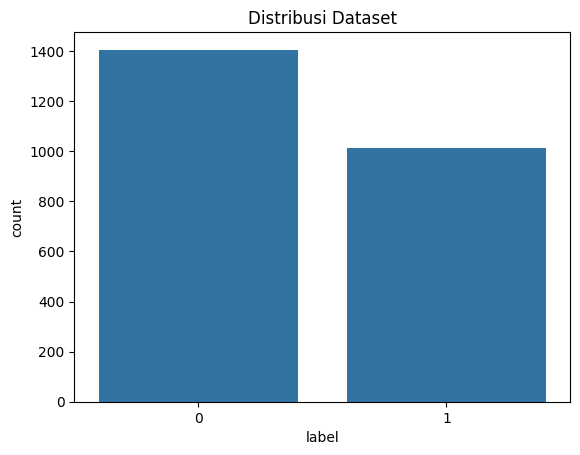

label
0    1405
1    1012
Name: count, dtype: int64


In [ ]:
sns.countplot(x=df['label'])
plt.title("Distribusi Dataset")
plt.show()

print(df['label'].value_counts())

TRAIN/VAL/TEST SPLIT

In [ ]:
df_trainval, df_test = train_test_split(
    df,
    test_size=0.15,
    random_state=SEED,
    stratify=df['label'])

df_train, df_val = train_test_split(
    df_trainval,
    test_size=0.176,
    random_state=SEED,
    stratify=df_trainval['label'])

print("Train:", len(df_train))
print("Val:", len(df_val))
print("Test:", len(df_test))

Train: 1692
Val: 362
Test: 363


PREPROCESSING RETINA

In [ ]:
def preprocess_retina(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
    green = img[:,:,1]

    clahe = cv2.createCLAHE(
        clipLimit=4.0,
        tileGridSize=(8,8))

    green = clahe.apply(green)
    img[:,:,1] = green

    return img

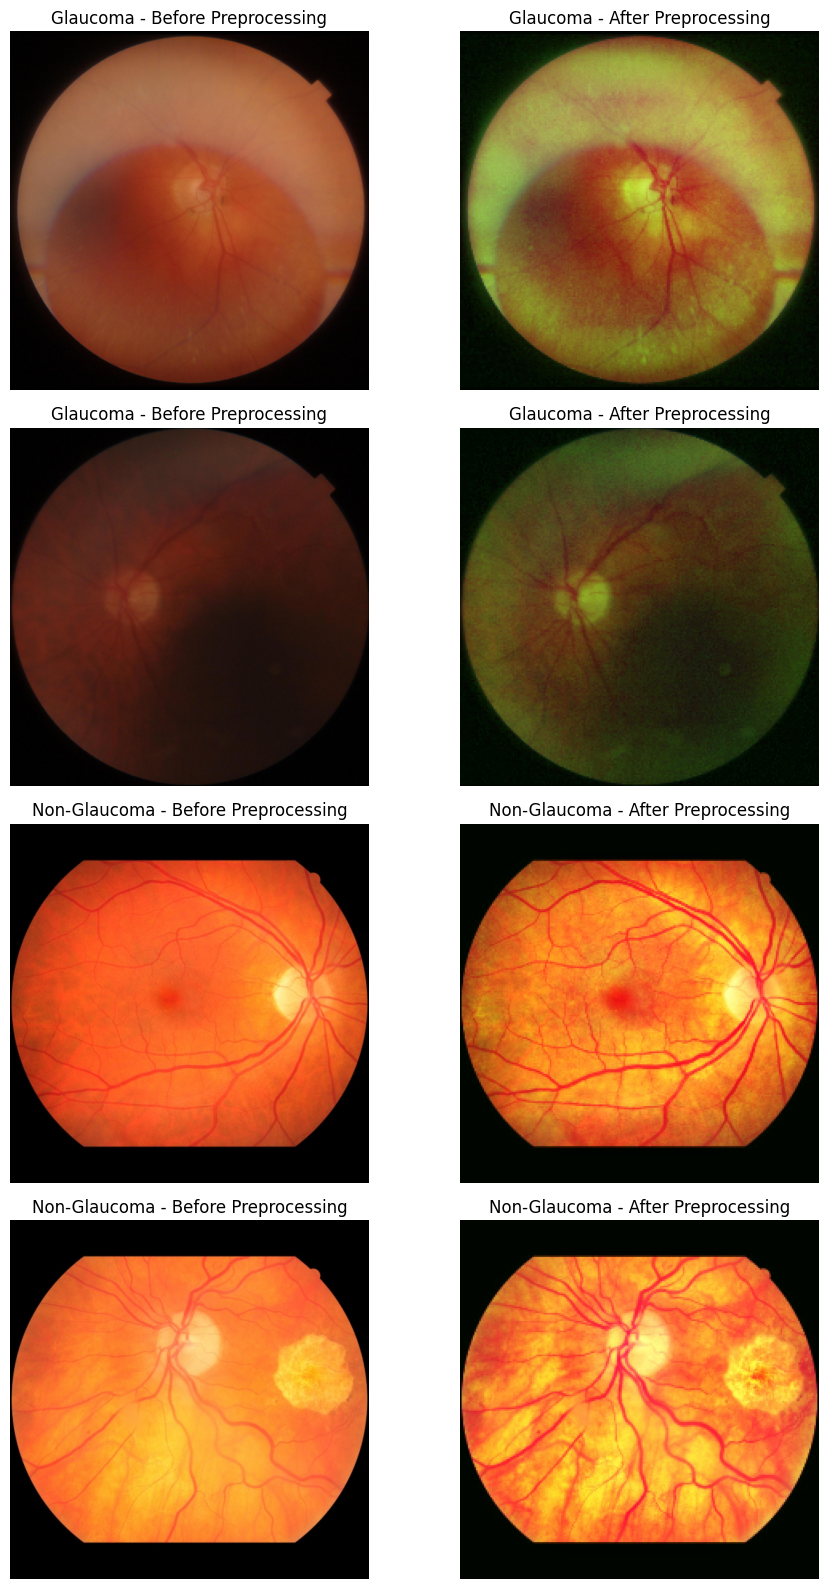

In [ ]:
glaucoma_samples = df[df['label'] == 1].sample(2)
normal_samples = df[df['label'] == 0].sample(2)

samples = pd.concat([glaucoma_samples, normal_samples])

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(10,16)
)

for i, (_, row) in enumerate(samples.iterrows()):

    # LOAD ORIGINAL IMAGE
    img_bgr = cv2.imread(row['filepath'])

    img_original = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2RGB
    )

    # PREPROCESS IMAGE
    img_processed = preprocess_retina(img_bgr)

    # LABEL
    label_name = (
        "Glaucoma"
        if row['label'] == 1
        else "Non-Glaucoma"
    )

    # ORIGINAL
    axes[i,0].imshow(img_original)
    axes[i,0].set_title(
        f'{label_name} - Before Preprocessing'
    )
    axes[i,0].axis('off')

    # PROCESSED
    axes[i,1].imshow(img_processed)
    axes[i,1].set_title(
        f'{label_name} - After Preprocessing'
    )
    axes[i,1].axis('off')

plt.tight_layout()
plt.show()

AUGMENTATION

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = A.Compose([
    A.RandomResizedCrop(
        size=(IMAGE_SIZE, IMAGE_SIZE),
        scale=(0.8, 1.0),
        p=1),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=30,
        p=0.5),
    A.HueSaturationValue(p=0.3),
    A.CLAHE(p=0.3),
    A.CoarseDropout(
        num_holes_range=(1,4),
        hole_height_range=(16,32),
        hole_width_range=(16,32),
        p=0.3),
    A.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD),
    ToTensorV2()])

val_transforms = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()])

DATASET CLASS

In [ ]:
class GlaucomaDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = torch.tensor(row['label'], dtype=torch.float32)
        img = cv2.imread(row['filepath'])
        img = preprocess_retina(img)

        if self.transform:
            img = self.transform(image=img)['image']
        return img, label

DATALOADER

In [ ]:
train_dataset = GlaucomaDataset(
    df_train,
    transform=train_transforms)

val_dataset = GlaucomaDataset(
    df_val,
    transform=val_transforms)

test_dataset = GlaucomaDataset(
    df_test,
    transform=val_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS)

MODEL MobileNetV3 + MLP

In [ ]:
class GlaucomaClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = timm.create_model(
            MODEL_NAME,
            pretrained=True,
            num_classes=0,
            global_pool='avg')
        n_features = 1280
        print("Feature Size:", n_features)

        self.classifier = nn.Sequential(
            nn.Linear(n_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1))

    def forward(self, x):
        features = self.backbone(x)
        logits = self.classifier(features)
        return logits.squeeze(1)

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

LOAD MODEL

In [ ]:
model = GlaucomaClassifier().to(DEVICE)
model.freeze_backbone()

model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

Feature Size: 1280


FOCAL LOSS

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce)
        alpha = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss = alpha * (1 - pt) ** self.gamma * bce

        return loss.mean()

OPTIMIZER

In [ ]:
criterion = FocalLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

TRAINING FUNCTION

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0

    all_preds = []
    all_labels = []

    for images, labels in tqdm(
        loader,
        desc='[TRAIN]',
        leave=False
    ):

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0)
        optimizer.step()
        running_loss += (
            loss.item() * images.size(0))
        probs = torch.sigmoid(logits).detach()
        all_preds.append(probs)
        all_labels.append(labels.detach().long())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    epoch_loss = (running_loss / len(loader.dataset))
    epoch_auc = auc_metric(all_preds, all_labels).item()
    epoch_acc = acc_metric(all_preds,all_labels).item()
    auc_metric.reset()
    acc_metric.reset()

    return (epoch_loss, epoch_auc, epoch_acc)

METRICS

In [ ]:
auc_metric = AUROC(task='binary').to(DEVICE)
acc_metric = Accuracy(task='binary').to(DEVICE)
f1_metric = F1Score(task='binary').to(DEVICE)
precision_metric = Precision(task='binary').to(DEVICE)
recall_metric = Recall(task='binary').to(DEVICE)

TRAIN FUNCTION

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0

    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(logits, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(logits).detach()

        all_preds.append(probs)
        all_labels.append(labels.long())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    epoch_loss = running_loss / len(loader.dataset)
    epoch_auc = auc_metric(all_preds, all_labels).item()
    epoch_acc = acc_metric(all_preds, all_labels).item()

    auc_metric.reset()
    acc_metric.reset()

    return epoch_loss, epoch_auc, epoch_acc

VALIDATION FUNCTION

In [ ]:
@torch.no_grad()

def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        logits = model(images)

        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)

        all_preds.append(torch.sigmoid(logits))
        all_labels.append(labels.long())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    epoch_loss = running_loss / len(loader.dataset)
    epoch_auc = auc_metric(all_preds, all_labels).item()
    epoch_acc = acc_metric(all_preds, all_labels).item()
    epoch_f1 = f1_metric(all_preds, all_labels).item()
    epoch_precision = precision_metric(all_preds, all_labels).item()
    epoch_recall = recall_metric(all_preds, all_labels).item()

    auc_metric.reset()
    acc_metric.reset()
    f1_metric.reset()
    precision_metric.reset()
    recall_metric.reset()

    return (epoch_loss, epoch_auc, epoch_acc, epoch_f1, epoch_precision, epoch_recall)

TRAINING LOOP

In [ ]:
history = {
    'train_loss': [],
    'val_loss': [],
    'train_auc': [],
    'val_auc': [],
    'train_acc': [],
    'val_acc': [],
    'val_f1': [],
    'val_precision': [],
    'val_recall': [],
    'lr': []}

best_auc = 0.0
patience_ctr = 0
CHECKPOINT = '/content/best_model.pth'

RUN TRAINING

In [ ]:
for epoch in range(1, EPOCHS + 1):

    if epoch == WARMUP_EPOCHS + 1:
        print("\nUNFREEZE BACKBONE")
        model.unfreeze_backbone()

        optimizer = optim.AdamW(
            model.parameters(),
            lr=LR * 0.1)

        scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

    current_lr = optimizer.param_groups[0]['lr']

    tr_loss, tr_auc, tr_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer)

    vl_loss, vl_auc, vl_acc, vl_f1, vl_precision, vl_recall = validate(
        model,
        val_loader,
        criterion)

    scheduler.step()
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_auc'].append(tr_auc)
    history['val_auc'].append(vl_auc)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['val_f1'].append(vl_f1)
    history['val_precision'].append(vl_precision)
    history['val_recall'].append(vl_recall)
    history['lr'].append(current_lr)

    print(
        f'Epoch {epoch:02d}/{EPOCHS} | '
        f'LR={current_lr:.1e} | '
        f'Train Loss={tr_loss:.4f} '
        f'AUC={tr_auc:.4f} | '
        f'Val Loss={vl_loss:.4f} '
        f'AUC={vl_auc:.4f} '
        f'ACC={vl_acc:.4f} '
        f'F1={vl_f1:.4f} '
        f'PREC={vl_precision:.4f} '
        f'REC={vl_recall:.4f}')

    if vl_auc > best_auc:
        best_auc = vl_auc
        patience_ctr = 0

        torch.save({
            'model_state_dict':model.state_dict(),
            'best_auc':best_auc
        }, CHECKPOINT)
        print('BEST MODEL SAVED')

    else:
        patience_ctr += 1
        print(f'No improvement ({patience_ctr}/{PATIENCE})')

    if patience_ctr >= PATIENCE:
        print('EARLY STOPPING')
        break

  0%|          | 0/106 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

Epoch 01/30 | LR=1.0e-04 | Train Loss=0.0703 AUC=0.6140 | Val Loss=0.0644 AUC=0.7725 ACC=0.4171 F1=0.5887 PREC=0.4183 REC=0.9934
BEST MODEL SAVED


  0%|          | 0/106 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

...

  0%|          | 0/23 [00:00<?, ?it/s]

Epoch 29/30 | LR=1.3e-06 | Train Loss=0.0503 AUC=0.8307 | Val Loss=0.0517 AUC=0.8249 ACC=0.7735 F1=0.7113 PREC=0.7652 REC=0.6645
BEST MODEL SAVED


  0%|          | 0/106 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

Epoch 30/30 | LR=9.5e-07 | Train Loss=0.0506 AUC=0.8414 | Val Loss=0.0517 AUC=0.8245 ACC=0.7652 F1=0.7099 PREC=0.7376 REC=0.6842
No improvement (1/8)


VISUALISASI HASIL

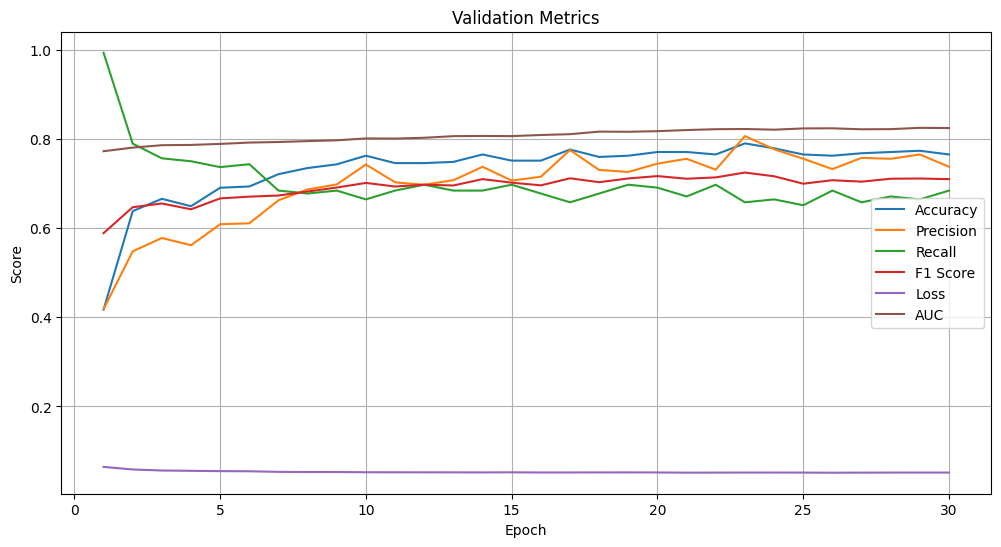

In [ ]:
epochs = range(1, len(history['val_acc']) + 1)

plt.figure(figsize=(12,6))

plt.plot(epochs, history['val_acc'], label='Accuracy')
plt.plot(epochs, history['val_precision'], label='Precision')
plt.plot(epochs, history['val_recall'], label='Recall')
plt.plot(epochs, history['val_f1'], label='F1 Score')
plt.plot(epochs, history['val_loss'], label='Loss')
plt.plot(epochs, history['val_auc'], label='AUC')

plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Validation Metrics')
plt.legend()
plt.grid(True)

plt.show()

FINAL VALIDATION METRIKS

In [ ]:
print(f"Loss: {history['val_loss'][-1]:.4f}")
print(f"AUC: {history['val_auc'][-1]:.4f}")
print(f"Accuracy: {history['val_acc'][-1]:.4f}")
print(f"F1 Score: {history['val_f1'][-1]:.4f}")
print(f"Precision: {history['val_precision'][-1]:.4f}")
print(f"Recall: {history['val_recall'][-1]:.4f}")

Loss: 0.0517
AUC: 0.8245
Accuracy: 0.7652
F1 Score: 0.7099
Precision: 0.7376
Recall: 0.6842


HASIL EPOCH TERBAIK

In [ ]:
best_epoch = np.argmax(history['val_auc'])

print(f"Best Epoch: {best_epoch+1}")

print(f"Best Loss: {history['val_loss'][best_epoch]:.4f}")
print(f"Best AUC: {history['val_auc'][best_epoch]:.4f}")
print(f"Best Accuracy: {history['val_acc'][best_epoch]:.4f}")
print(f"Best F1 Score: {history['val_f1'][best_epoch]:.4f}")
print(f"Best Precision: {history['val_precision'][best_epoch]:.4f}")
print(f"Best Recall: {history['val_recall'][best_epoch]:.4f}")

Best Epoch: 29
Best Loss: 0.0517
Best AUC: 0.8249
Best Accuracy: 0.7735
Best F1 Score: 0.7113
Best Precision: 0.7652
Best Recall: 0.6645


Saving n0321.jpg to n0321.jpg


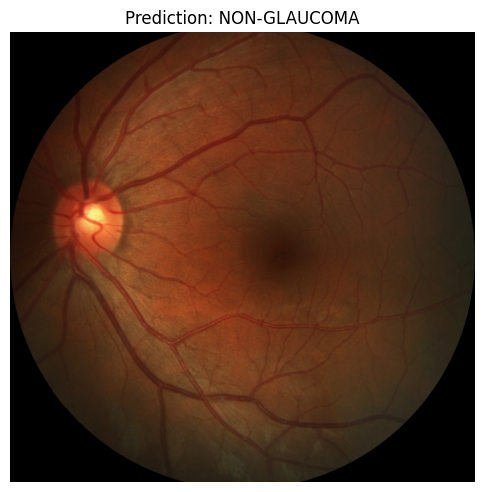

Probability Glaucoma : 0.4889
Prediction           : NON-GLAUCOMA


In [ ]:
from google.colab import files
from PIL import Image

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

processed = preprocess_retina(img_bgr)

tensor = val_transforms(image=processed)['image']
tensor = tensor.unsqueeze(0).to(DEVICE)

# prediksi
model.eval()
with torch.no_grad():
    logits = model(tensor)
    prob = torch.sigmoid(logits).item()

# klasifikasi
prediction = (
    "GLAUCOMA"
    if prob >= 0.5
    else "NON-GLAUCOMA")

#visualisasi
plt.imshow(img_rgb)
plt.title(f'Prediction: {prediction}')
plt.axis('off')
plt.show()

print(f'Probability Glaucoma : {prob:.4f}')
print(f'Prediction           : {prediction}')